Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning
(Remove corrupted / invalid images)
        ↓
Train / Validation / Test Split
        ↓
Image Transformations
        ↓
Create Dataset
(ImageFolder)
        ↓
Create DataLoaders
        ↓
Visualize Images
        ↓
Baseline CNN
(Custom CNN Architecture)
        ↓
Choose Loss Function
        ↓
Choose Optimizer
        ↓
Training Loop
        ↓
Validation
        ↓
Hyperparameter Tuning
(Optional)
        ↓
Model Evaluation
        ↓
        ┌──────────────────────────────┐
        │      Improve Performance     │
        └──────────────┬───────────────┘
                       ↓
               Transfer Learning
                       ↓
          Choose Pretrained Model
      (ResNet / EfficientNet / MobileNet)
                       ↓
             Modify Classifier
                       ↓
             Freeze / Unfreeze Layers
                       ↓
              Fine-Tuning
                       ↓
              Model Evaluation
                       ↓
             Compare Models
          Custom CNN vs Pretrained
                       ↓
               Select Best Model
                       ↓
              Save Trained Model
                       ↓
             Inference / Prediction
                       ↓
              Deployment (Streamlit)
                       ↓
                GitHub + README

In [2]:
# import torch
import os
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cu128
CUDA Available: True
Using Device: cuda
GPU: Tesla T4


<b>Project Goal :</b>

The goal of this project is to build a deep learning image classification system using CNNs (Convolutional Neural Networks) that can analyze chest X-ray images and classify them into predefined categories such as Normal and Pneumonia.

The project will demonstrate how computer vision and deep learning can be used to extract visual patterns from medical images and perform automated image classification.

<mark>This project is for educational and machine-learning demonstration purposes only and is not intended for medical diagnosis or clinical decision-making.

In [3]:
#next stpe: Data Collection

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Shipsense', '"I am restarting my study journey after a 6.5-yea....gsheet', 'Google AI Studio', 'chest_xray_dataset', 'chest_xray_splitted', 'chest_xray_model_bht.pth', 'chest_xray_checkpoint_bht.pth', 'class_to_idx_bht.json', 'chest_xray_model_best.pth']


In [5]:
import os

print(os.listdir("/content/drive/MyDrive/chest_xray_dataset"))

['NORMAL ', 'PNEUMONIA ']


In [6]:
dataset_path = r"/content/drive/MyDrive/chest_xray_dataset"

normal_path = os.path.join(dataset_path, "NORMAL ")
pneumonia_path = os.path.join(dataset_path, "PNEUMONIA ")

print("NORMAL images:", len(os.listdir(normal_path)))
print("PNEUMONIA images:", len(os.listdir(pneumonia_path)))

NORMAL images: 1583
PNEUMONIA images: 4273


#dataset understanding

In this step, we will analyze the structure and characteristics of the
Chest X-Ray dataset before performing data cleaning and splitting.

We will inspect:

- Number of images in each class
- Total number of images
- Image dimensions
- Image channels
- File formats
- Sample images
- Class distribution

In [7]:
#no. of images in all classes


dataset_path = r"/content/drive/MyDrive/chest_xray_dataset"

normal_path = os.path.join(dataset_path, "NORMAL ")
pneumonia_path = os.path.join(dataset_path, "PNEUMONIA ")

print("NORMAL images:", len(os.listdir(normal_path)))
print("PNEUMONIA images:", len(os.listdir(pneumonia_path)))

NORMAL images: 1583
PNEUMONIA images: 4273


In [ ]:
#total number of images

len(os.listdir(normal_path)) + len(os.listdir(pneumonia_path))

5856

In [ ]:
#specifying the folder paths

dataset_path = r"/content/drive/MyDrive/chest_xray_dataset"

normal_path = os.path.join(dataset_path, "NORMAL ")
pneumonia_path = os.path.join(dataset_path, "PNEUMONIA ")

In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
import os

print(os.listdir(dataset_path))

print(os.listdir(normal_path))

print(os.listdir(pneumonia_path))

['NORMAL ', 'PNEUMONIA ']
['NORMAL-4199443-0002.jpeg', 'NORMAL-4240389-0001.jpeg', 'NORMAL-4241389-0001.jpeg', 'NORMAL-4190414-0001.jpeg', 'NORMAL-4178256-0001.jpeg', 'NORMAL-4486854-0001.jpeg', 'NORMAL-4316614-0001.jpeg', 'NORMAL-4499436-0001.jpeg', 'NORMAL-4418958-0001.jpeg', 'NORMAL-4496165-0001.jpeg', 'NORMAL-4358449-0001.jpeg', 'NORMAL-4507677-0002.jpeg', 'NORMAL-4320287-0001.jpeg', 'NORMAL-4500184-0001.jpeg', 'NORMAL-447225-0001.jpeg', 'NORMAL-4315572-0001.jpeg', 'NORMAL-4418958-0003.jpeg', 'NORMAL-4418958-0004.jpeg', 'NORMAL-4358449-0002.jpeg', 'NORMAL-4464072-0001.jpeg', 'NORMAL-4316614-0002.jpeg', 'NORMAL-4418958-0002.jpeg', 'NORMAL-4377146-0001.jpeg', 'NORMAL-4363211-0001.jpeg', 'NORMAL-4340661-0001.jpeg', 'NORMAL-4320287-0002.jpeg', 'NORMAL-4447575-0001.jpeg', 'NORMAL-445267-0001.jpeg', 'NORMAL-4421061-0001.jpeg', 'NORMAL-4317334-0001.jpeg', 'NORMAL-4507677-0001.jpeg', 'NORMAL-4513268-0001.jpeg', 'NORMAL-4649665-0001.jpeg', 'NORMAL-4515478-0001.jpeg', 'NORMAL-4515478-0002.jp

In [8]:
#checking dimensions of images


from PIL import Image
import os

image_name = os.listdir(normal_path)[0]

image_path = os.path.join(normal_path, image_name)

with Image.open(image_path) as img:
    print("Image dimensions:", img.size)

Image dimensions: (1728, 1619)


In [ ]:
#lets inspect a image from the dataset

normal_images = os.listdir(normal_path)

image_1 = os.path.join(normal_path, normal_images[727])

print(image_1)

/content/drive/MyDrive/chest_xray_dataset/NORMAL /NORMAL-8416635-0001.jpeg


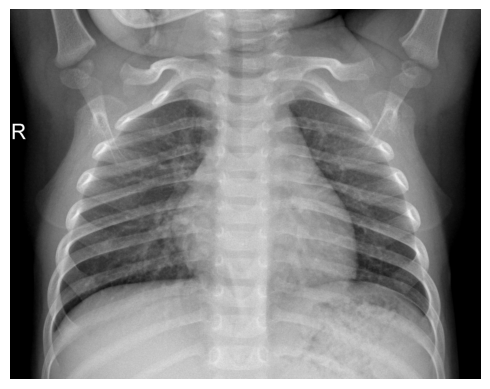

In [ ]:
import matplotlib.pyplot as plt

img = Image.open(image_1)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
#last: lets check image channels

with Image.open(image_path) as img:
    print("Image mode:", img.mode)

Image mode: L


# analysis about image channels


L → 1 channel

RGB → 3 channels

RGBA → 4 channels

<mark>so , our dataset images containes only 1 channel / grayscale

Formats = .jpeg

#data understanding done now next step is : Data Cleaning (Remove corrupted / invalid images)


<mark>In this step, we will identify corrupted or invalid image files
before splitting the dataset into training, validation, and testing sets.

We will detect:


Corrupted JPEG files

Files that cannot be opened

Zero-byte/invalid image files

Files with invalid image content

Non-image files accidentally present in the folders

In [ ]:
#removing file that are not jpeg from normal folder


normal_files = os.listdir(normal_path)

count = 0

for file in normal_files:

    if not file.lower().endswith((".jpg", ".jpeg", ".png")):
        count = count+1
        print("Non-image file:", file)

print(f"{count} non-image files found")

0 non-image files found


In [ ]:
#same with pneumonia folder


pneumonia_files = os.listdir(pneumonia_path)


count = 0

for file in pneumonia_files:
  if not file.lower().endswith(('.jpg','.jpeg','.png')):
    count = count +1
    print("Non image files ",file)


print(count)

0


In [ ]:
# now lets find Zero-byte files

os.path.getsize(r'/content/drive/MyDrive/chest_xray_dataset/NORMAL /NORMAL-8416635-0001.jpeg')

#from normal folder

normal_files = os.listdir(normal_path)
count = 0
for file in normal_files:

    file_path = os.path.join(normal_path, file)
    if os.path.getsize(file_path) == 0:
        print("Zero-byte file:", file)
        count = count + 1

print(count)


0


In [ ]:
#same with pneumonia folder

pneumonia_files = os.listdir(pneumonia_path)

count = 0

for file in pneumonia_files:
  file_path = os.path.join(pneumonia_path,file)

  if os.path.getsize(file_path) == 0:
    print("Zero-byte file:",file)
    count = count + 1

print(count)


0



<b> Data Cleaning Done Now next step is :Train / Validation / Test Split

In [ ]:
# Train / Validation / Test Split


# We'll use:

# 70% → Train
# 15% → Validation
# 15% → Test


In [9]:
#lets provides all folder paths

output_path = "/content/drive/MyDrive/chest_xray_splitted"

dataset_path = r"/content/drive/MyDrive/chest_xray_dataset"

normal_path = os.path.join(dataset_path, "NORMAL ")
pneumonia_path = os.path.join(dataset_path, "PNEUMONIA ")


In [ ]:
#after creating paths we will make folders such as "train", "validation", "test"

for split in ["train", "validation", "test"]:

    for category in ["NORMAL", "PNEUMONIA"]:

        os.makedirs(
            os.path.join(output_path, split, category),
            exist_ok=True
        )

In [ ]:
#now folders are created but empty
# we need to split images as well

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15


normal_files = os.listdir(normal_path)
pneumonia_files = os.listdir(pneumonia_path)

#shuffle them for better accuracy uaing random

import random

random.shuffle(normal_files)
random.shuffle(pneumonia_files)

In [ ]:
train_end = int(len(normal_files) * train_ratio)
val_end = train_end + int(len(normal_files) * val_ratio)
test_end = val_end + int(len(normal_files) * test_ratio)

print(train_end)
print(val_end)
print(test_end)

1108
1345
1582


| Section       |       Indices | Approx. images |
| ------------- | ------------: | -------------: |
| 🟢 Train      |    `0 → 1107` |           1108 |
| 🟡 Validation | `1108 → 1344` |            237 |
| 🔵 Test       | `1345 → 1581` |            237 |


In [ ]:
train_normal = normal_files[:train_end]

val_normal = normal_files[train_end:val_end]

test_normal = normal_files[val_end:]

In [ ]:
print("Train:", len(train_normal))
print("Validation:", len(val_normal))
print("Test:", len(test_normal))

Train: 1108
Validation: 237
Test: 238


In [ ]:
#same for pneumonial folder

pneumonia_files = os.listdir(pneumonia_path)
train_end = int(len(pneumonia_files) * train_ratio)

val_end = train_end + int(len(pneumonia_files) * val_ratio)

test_end = val_end + int(len(pneumonia_files) * test_ratio)

print(train_end)
print(val_end)
print(test_end)


train_pneumonia = pneumonia_files[:train_end]

val_pneumonia = pneumonia_files[train_end:val_end]

test_pneumonia = pneumonia_files[val_end:]

2991
3631
4271


In [ ]:
print("Train:", len(train_pneumonia))
print("Validation:", len(val_pneumonia))
print("Test:", len(test_pneumonia))

Train: 2991
Validation: 640
Test: 642


In [ ]:
#till now we just created structure we didnt added any image yet

import shutil

for file in train_normal:
    src = os.path.join(normal_path, file)
    dst = os.path.join(output_path, "train", "NORMAL", file)
    shutil.copy(src, dst)

print("Train NORMAL images copied:", len(train_normal))

KeyboardInterrupt: 

In [ ]:
for file in val_normal:
    src = os.path.join(normal_path, file)
    dst = os.path.join(output_path, "validation", "NORMAL", file)
    shutil.copy(src, dst)

print("Validation NORMAL images copied:", len(val_normal))

In [ ]:
for file in test_normal:
    src = os.path.join(normal_path, file)
    dst = os.path.join(output_path, "test", "NORMAL", file)
    shutil.copy(src, dst)

print("Test NORMAL images copied:", len(test_normal))

In [ ]:
for file in train_pneumonia:
    src = os.path.join(pneumonia_path, file)
    dst = os.path.join(output_path, "train", "PNEUMONIA", file)
    shutil.copy(src, dst)

print("Train PNEUMONIA images copied:", len(train_pneumonia))

In [ ]:
for file in val_pneumonia:
    src = os.path.join(pneumonia_path, file)
    dst = os.path.join(output_path, "validation", "PNEUMONIA", file)
    shutil.copy(src, dst)

print("Validation PNEUMONIA images copied:", len(val_pneumonia))

In [ ]:
for file in test_pneumonia:
    src = os.path.join(pneumonia_path, file)
    dst = os.path.join(output_path, "test", "PNEUMONIA", file)
    shutil.copy(src, dst)

print("Test PNEUMONIA images copied:", len(test_pneumonia))

In [10]:
for split in ["train", "validation", "test"]:
    for category in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(output_path, split, category)
        print(split, category, "->", len(os.listdir(folder)))

train NORMAL -> 1107
train PNEUMONIA -> 2991
validation NORMAL -> 237
validation PNEUMONIA -> 640
test NORMAL -> 238
test PNEUMONIA -> 642


<b><strong> Image Transformations

In [ ]:
from PIL import Image
import os

def find_and_remove_corrupt_images(root_dir, remove=True):
    bad_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            fpath = os.path.join(dirpath, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()          # checks integrity without fully decoding
            except Exception as e:
                bad_files.append(fpath)
                print("Corrupt:", fpath, "->", e)

    print(f"\nFound {len(bad_files)} corrupt files")

    if remove:
        for fpath in bad_files:
            os.remove(fpath)
        print(f"Removed {len(bad_files)} corrupt files")

    return bad_files

corrupt = find_and_remove_corrupt_images(output_path, remove=True)

Corrupt: /content/drive/MyDrive/chest_xray_splitted/train/NORMAL/NORMAL-2337422-0001.jpeg -> cannot identify image file '/content/drive/MyDrive/chest_xray_splitted/train/NORMAL/NORMAL-2337422-0001.jpeg'

Found 1 corrupt files
Removed 1 corrupt files


  
# We have to convert images into tensors

Image File (.jpg)

        │
        ▼
Open Image

        │
        ▼
Resize

        │
        ▼
Convert to Tensor

        │
        ▼
Normalize

        │
        ▼
CNN

In [11]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Compose() combines multiple transformations into a single pipeline.
#
# Images are resized to 96×96 to reduce computational cost.
# 96×96 contains ~5.4× fewer pixels than 224×224,
# making convolution operations significantly cheaper.
#
# AdaptiveAvgPool2d allows the CNN to handle the resulting
# feature maps without requiring a fixed spatial size beforehand.

In [12]:
#also normalizing bcoz It puts the input values into a more standardized range, which can help the neural network train more smoothly and efficiently

In [13]:
#till then we only created pipeline and no image has transformed yet


from torchvision.datasets import ImageFolder

#providing all paths


train_dataset = ImageFolder(
    root=os.path.join(output_path, "train"),
    transform=transform
)

validation_dataset = ImageFolder(
    root=os.path.join(output_path, "validation"),
    transform=transform
)

test_dataset = ImageFolder(
    root=os.path.join(output_path, "test"),
    transform=transform
)

In [14]:
print("Train Images      :", len(train_dataset))
print("Validation Images :", len(validation_dataset))
print("Test Images       :", len(test_dataset))

Train Images      : 4098
Validation Images : 877
Test Images       : 880


In [15]:
print(train_dataset.classes)
print(train_dataset.class_to_idx)



print(test_dataset.classes)

print(validation_dataset.classes)

print(train_dataset.class_to_idx)

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}
['NORMAL', 'PNEUMONIA']
['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [17]:
# now import dataloader so that we can send images in batches


In [18]:
from torch.utils.data import DataLoader

In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

#batch size = 64 and num_worker will be 2 we will optimise it later

In [20]:
#lets check if everything alright

print(len(train_loader))
print(len(validation_loader))
print(len(test_loader))

65
14
14


In [21]:
64*65

4160

In [27]:
#lets verify shape of a image from 1 batch

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

KeyboardInterrupt: 

# [64, 1,96,96]

batch , 1 channel(Because images in datasets are grayscaled) , height , width


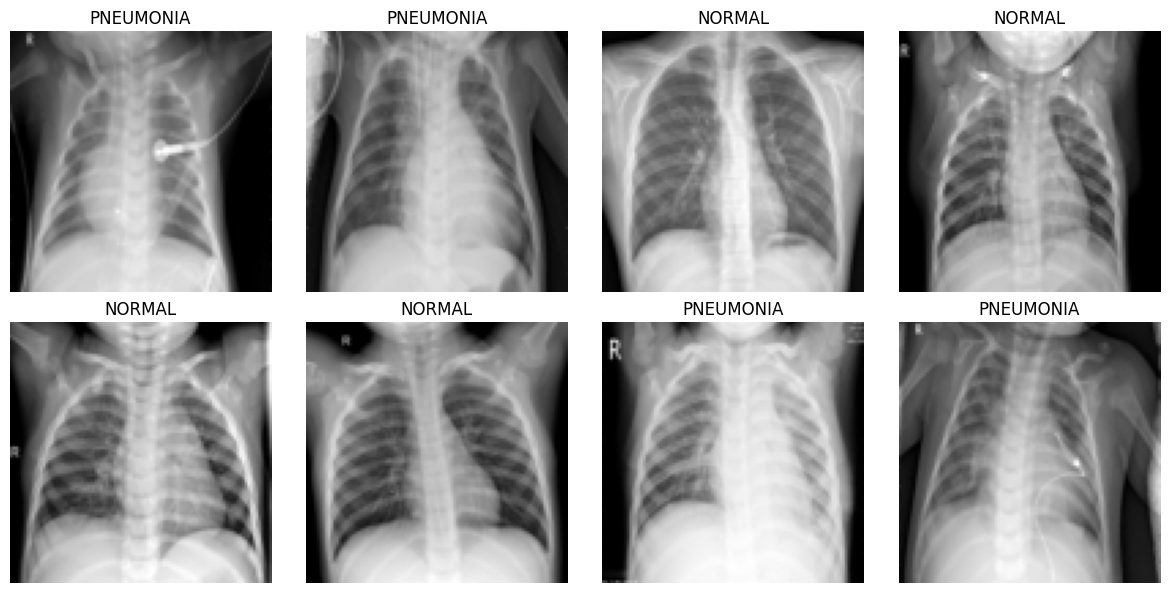

In [ ]:
#lets visualise images before moving forward

import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax in axes.flat:
    index = random.randint(0, len(train_dataset) - 1)

    image, label = train_dataset[index]

    image = image.squeeze(0)      # [1, 96, 96] → [96, 96]
    image = image * 0.5 + 0.5    # Undo normalization

    ax.imshow(image, cmap="gray")
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
#  Baseline CNN (Custom CNN Architecture)


import torch.nn as nn

class X_ray_Model(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(
        in_channels = 1,
        out_channels=32,
        kernel_size=3,
        padding = 1)

    self.relu = nn.ReLU()

    self.pool = nn.MaxPool2d(kernel_size = 2)


    #second layer


    self.conv2 = nn.Conv2d(
        in_channels = 32,
        out_channels=64,
        kernel_size=3,
        padding = 1)

    #3rd layer

    self.conv3 = nn.Conv2d(
        in_channels = 64,
        out_channels=128,
        kernel_size=3,
        padding = 1)

    #4th

    self.conv4 = nn.Conv2d(
        in_channels = 128,
        out_channels=256,
        kernel_size=3,
        padding = 1)

    self.gap = nn.AdaptiveAvgPool2d((4, 4))


    #flatten layer

    self.flatten = nn.Flatten()

    #no fully connected layers

    self.fc1 = nn.Linear(
        in_features = 4*4*256,
        out_features=512)

    self.fc2 = nn.Linear(
        in_features = 512,
        out_features=128)

    self.fc3 = nn.Linear(
        in_features = 128,
        out_features = 2)


  def forward(self,x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.conv2(x)
    x = self.relu(x)
    x = self.pool(x)


    x = self.conv3(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.conv4(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.gap(x)
    x = self.flatten(x)


    x = self.fc1(x)
    x = self.relu(x)

    x = self.fc2(x)
    x = self.relu(x)

    x = self.fc3(x)

    return x





In [24]:
4*4*256

4096

In [25]:
model = X_ray_Model()

print(model)

X_ray_Model(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (gap): AdaptiveAvgPool2d(output_size=(4, 4))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)


In [26]:
output = model(images)

print(output.shape)

NameError: name 'images' is not defined

[64,2] means 64 image in 1 batch and 2 classes

In [ ]:
images

tensor([[[[-0.6157, -0.4824, -0.3882,  ..., -0.2941, -0.3647, -0.4510],
          [-0.6157, -0.4902, -0.3882,  ..., -0.3020, -0.3333, -0.4118],
          [-0.6235, -0.4980, -0.3961,  ..., -0.3098, -0.3176, -0.3647],
          ...,
          [-1.0000, -1.0000, -0.9922,  ..., -0.7490, -0.9686, -1.0000],
          [-1.0000, -1.0000, -0.9922,  ..., -0.7176, -0.9686, -1.0000],
          [-1.0000, -1.0000, -0.9843,  ..., -0.6863, -0.9608, -1.0000]]],


        [[[-0.9843, -0.8980, -0.7569,  ..., -0.5373, -0.5843, -0.6627],
          [-0.9922, -0.9216, -0.7961,  ..., -0.5451, -0.6078, -0.6941],
          [-1.0000, -0.9529, -0.8353,  ..., -0.5608, -0.6314, -0.7255],
          ...,
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
          [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]]],


        [[[-0.5843, -0.4824, -0.1294,  ..., -0.0745, -0.0275, -0.1059],
          [-0.5843, -0.560

In [29]:
#Loss and optimiser

model = X_ray_Model().to(device)

criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(model.parameters(),lr=0.001)



In [30]:
print("Device:", device)
print("Model device:", next(model.parameters()).device)

Device: cuda
Model device: cuda:0


In [ ]:
# #now the training loop

# num_epochs = 12

# for epoch in range(num_epochs):
#   model.train()


#   running_loss = 0.0

#   for images,labels in train_loader:

#     optimizer.zero_grad()

#     output = model(images)

#     loss = criterion(output , labels)

#     loss.backward()

#     optimizer.step()

#     running_loss=running_loss+loss.item()

#   epoch_loss = running_loss / len(train_loader)

#   print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}")





In [32]:
#we nee dto trauin it on gpu

num_epochs = 12

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        output = model(images)

        loss = criterion(output, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/12] Loss: 0.5114
Epoch [2/12] Loss: 0.2991
Epoch [3/12] Loss: 0.1553
Epoch [4/12] Loss: 0.1261
Epoch [5/12] Loss: 0.1272
Epoch [6/12] Loss: 0.1011
Epoch [7/12] Loss: 0.0907
Epoch [8/12] Loss: 0.1524
Epoch [9/12] Loss: 0.0771
Epoch [10/12] Loss: 0.0660
Epoch [11/12] Loss: 0.0535
Epoch [12/12] Loss: 0.0555


In [33]:
import json

# ==== Save all model artifacts (BEFORE hyperparameter tuning) ====

save_dir = "/content/drive/MyDrive"

# 1. Model weights only
torch.save(model.state_dict(), f"{save_dir}/new_chest_xray_model_bht.pth")

# 2. Full checkpoint (for resuming training later if needed)
torch.save({
    "epoch": num_epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": epoch_loss,
}, f"{save_dir}/new_chest_xray_checkpoint_bht.pth")

# 3. Class-to-index mapping
with open(f"{save_dir}/new_class_to_idx_bht.json", "w") as f:
    json.dump(train_dataset.class_to_idx, f)

print("Saved: chest_xray_model_bht.pth, chest_xray_checkpoint_bht.pth, class_to_idx_bht.json")

Saved: chest_xray_model_bht.pth, chest_xray_checkpoint_bht.pth, class_to_idx_bht.json


In [ ]:
#validation

# =========================
# VALIDATION
# =========================

model.eval()

running_val_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in validation_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate validation loss
        loss = criterion(outputs, labels)

        running_val_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Count total images
        total += labels.size(0)

        # Count correct predictions
        correct += (predicted == labels).sum().item()


# Average validation loss
val_loss = running_val_loss / len(validation_loader)

# Validation accuracy
val_accuracy = 100 * correct / total


print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.2f}%")

#claude this notebook is not completed yet

please add more steps such as saving models(if any ) , evaluation and more neccercary steps if any because model is already trained his will be very easy for you and pleaseee write easy code dont complicate it after that write completed and end the notebook